In [7]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("ggplot")

In [8]:
DATA_PATH = Path("../data/processed/cleaned_data.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [9]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 12774
Columns : 8


In [10]:
df.describe()

,bath,balcony,price
count,12774.000000,12774.000000,12774.000000
mean,2.705417,1.601534,114.339147
std,1.355605,0.808135,151.506067
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,73.000000
75%,3.000000,2.000000,121.000000
max,40.000000,3.000000,3600.000000


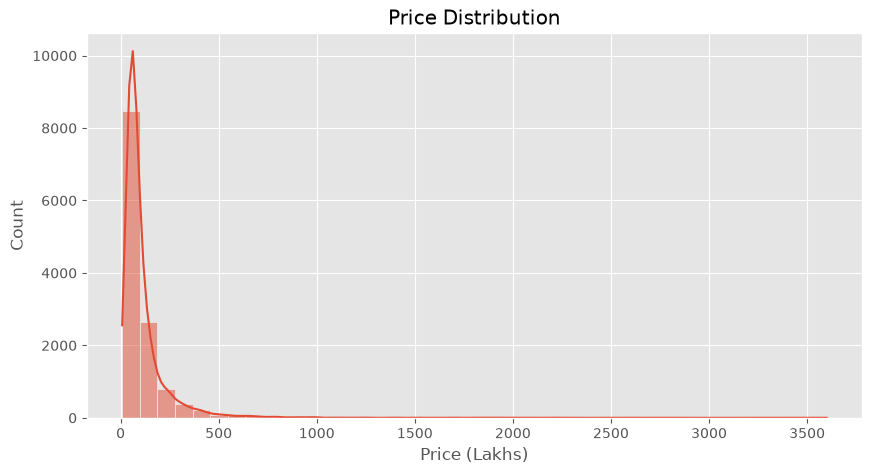

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(df["price"], bins=40, kde=True)

plt.title("Price Distribution")

plt.xlabel("Price (Lakhs)")

plt.show()

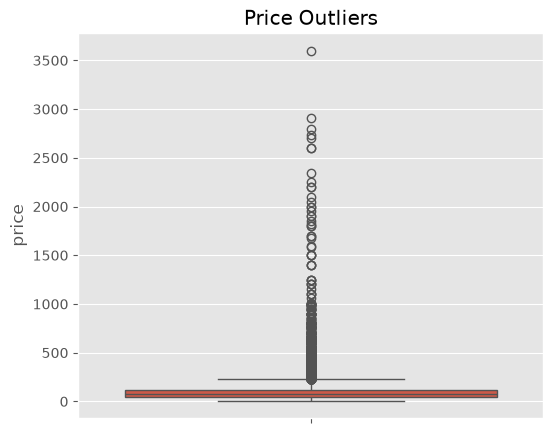

In [12]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df["price"])

plt.title("Price Outliers")

plt.show()

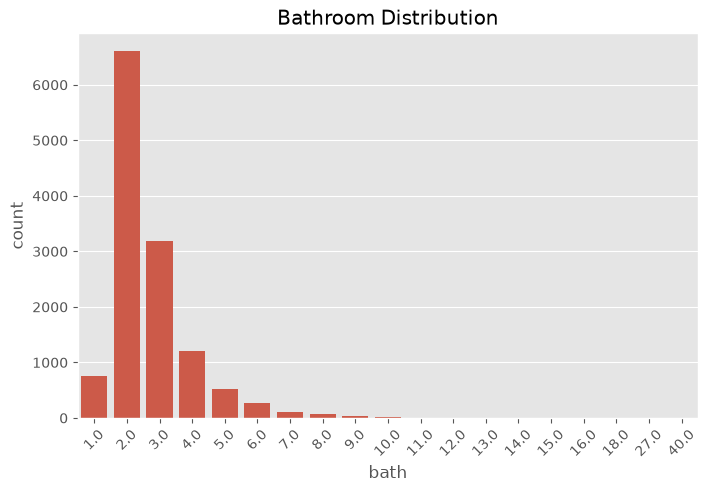

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(x=df["bath"])

plt.xticks(rotation=45)

plt.title("Bathroom Distribution")

plt.show()

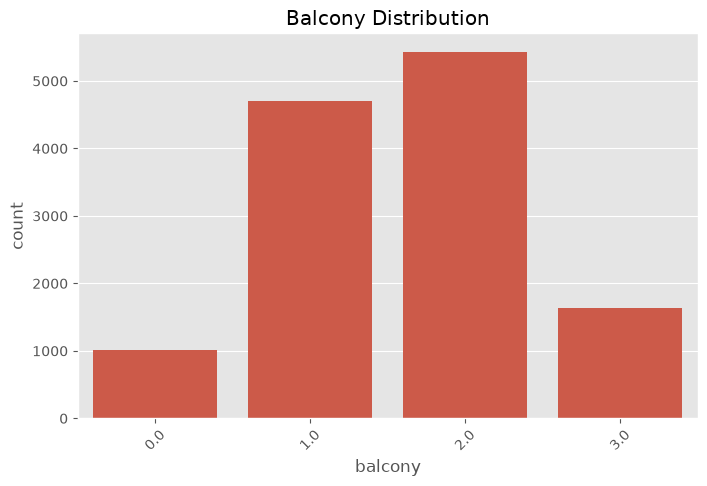

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(x=df["balcony"])

plt.xticks(rotation=45)

plt.title("Balcony Distribution")

plt.show()

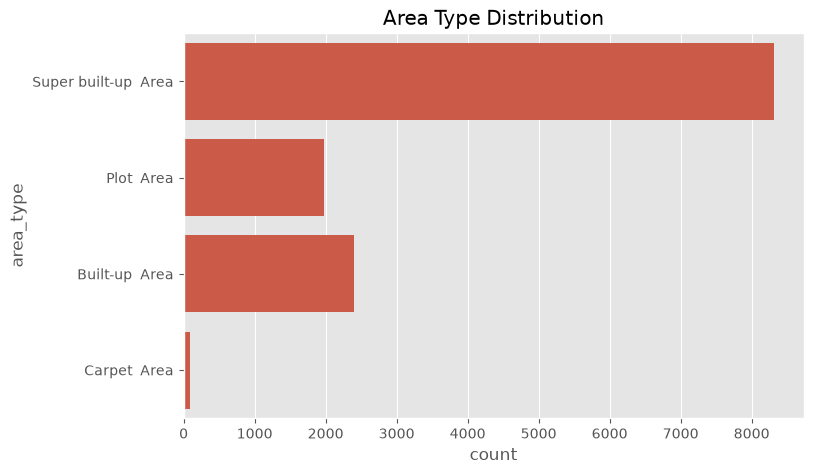

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(y=df["area_type"])

plt.title("Area Type Distribution")

plt.show()

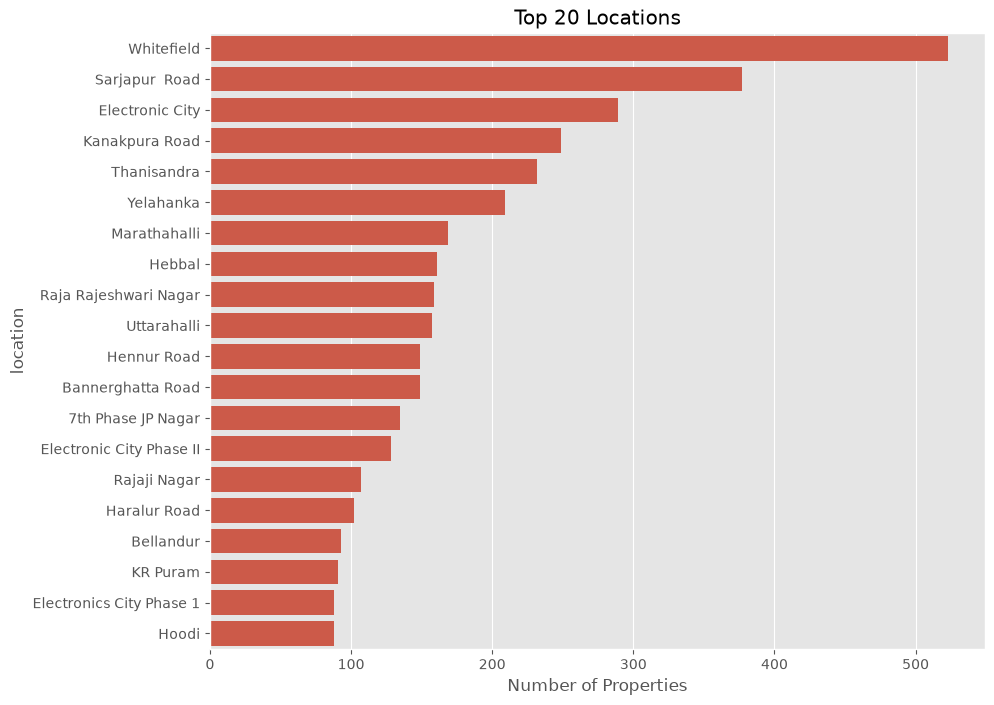

In [16]:
top_locations = df["location"].value_counts().head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)

plt.title("Top 20 Locations")

plt.xlabel("Number of Properties")

plt.show()

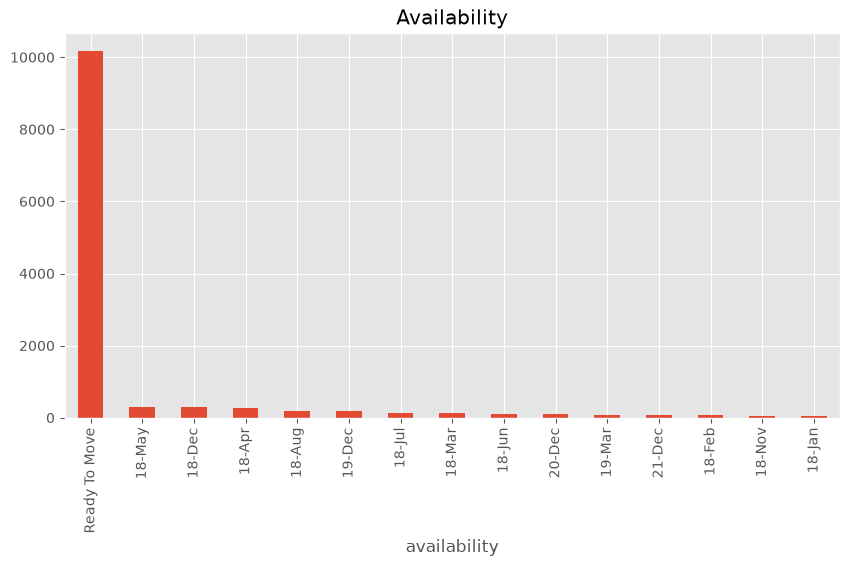

In [17]:
plt.figure(figsize=(10,5))

df["availability"].value_counts().head(15).plot(kind="bar")

plt.title("Availability")

plt.show()

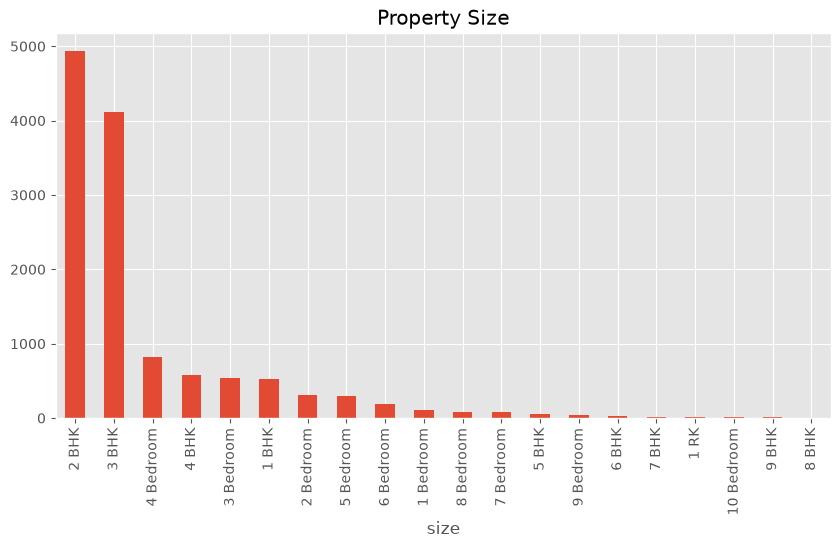

In [18]:
plt.figure(figsize=(10,5))

df["size"].value_counts().head(20).plot(kind="bar")

plt.title("Property Size")

plt.show()

In [19]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.head()

,bath,balcony,price
0,2.0,1.0,39.07
1,5.0,3.0,120.00
2,2.0,3.0,62.00
3,3.0,1.0,95.00
4,2.0,1.0,51.00


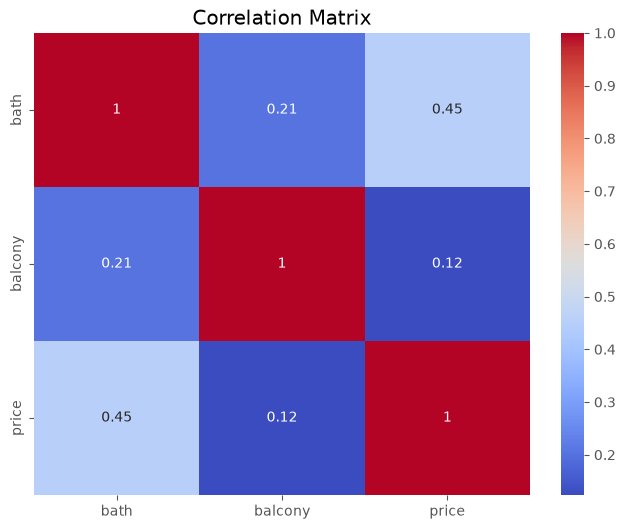

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

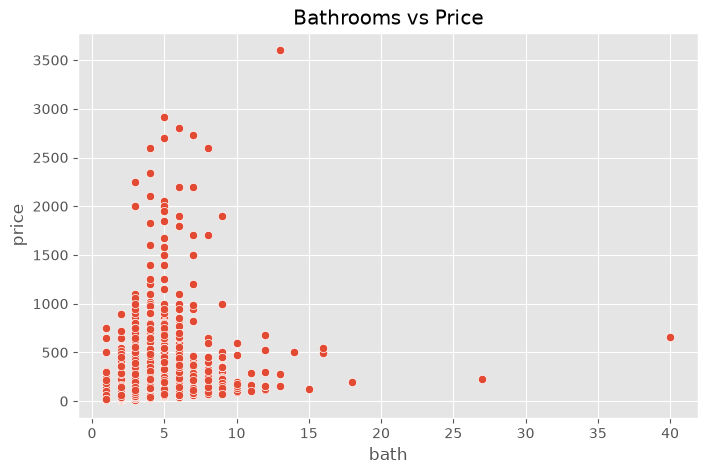

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["bath"],
    y=df["price"]
)

plt.title("Bathrooms vs Price")

plt.show()

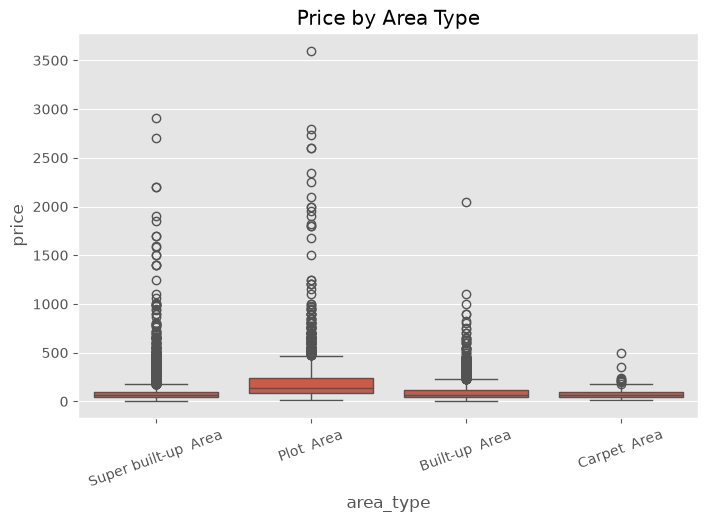

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["area_type"],
    y=df["price"]
)

plt.xticks(rotation=20)

plt.title("Price by Area Type")

plt.show()

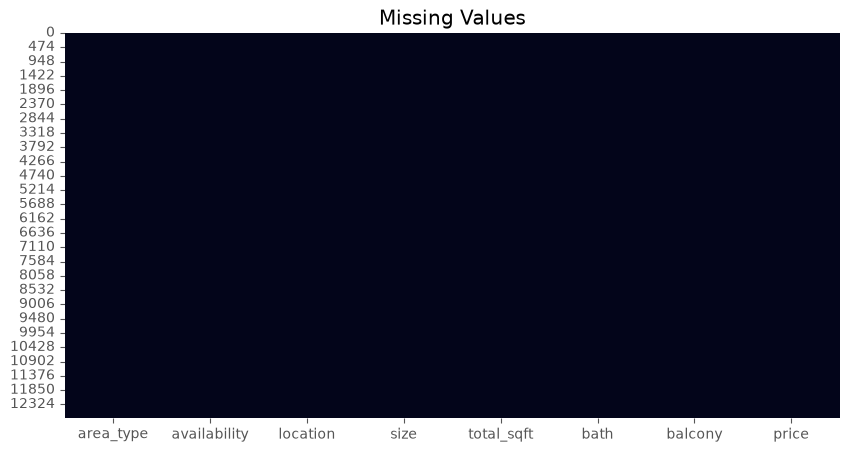

In [23]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")

plt.show()

# EDA Summary

- No missing values remain.
- Price distribution is right-skewed.
- Most properties have 2–3 bathrooms.
- Super built-up area is the most common area type.
- Some locations have significantly more listings than others.
- Price contains outliers that will be handled during feature engineering.